# E-commerce Sales Data Cleaning and Analysis

Dataset: 30,000 sales transactions

Goal:
Clean a messy sales dataset and prepare it for business analysis.

Importing **Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Loading **Dataset**

In [2]:
df = pd.read_csv("/content/drive/MyDrive/upwork/project 1/salesdata.csv")

df.head()

,Order ID,order_date,CUSTOMER name,Email Address,Phone,Product,Qty,Unit Price,Discount,total,Status,Shipping Address,city,STATE,ZIP
0,3380,05-26-2024,Jason Robinson,jason.robinson@gmail.com,984-883-4368,Cable Organizer,2,12.99,NaN,$25.98,Completed,1240 Maple Ct,Indianapolis,IN,46251
1,14479,2023/09/10,Kevin Martinez,kevin.martinez@gmail.com,(323) 373-2687,Smart Plug 4-Pack,4,29.99,5%,113.96,Shipped,6654 Oak St,philadelphia,PA,19183
2,8116,2024-03-09,Brenda Johnson,brenda.johnson@outlook.com,(695) 347-6984,Webcam,3,$89.99,NaN,$269.97,completed,5597 Pine Blvd,Boston,MA,2182
3,2486,"Dec 17, 2024",Richard Clark,richard.clark@yahoo.com,844-373-9297,Laptop Stand,4,45.00,5%,$171.00,PENDING,4898 Walnut Dr,Dallas,TX,75282
4,11316,06-25-2024,Paul Lewis,paul.lewis@aol.com,+16567855167,Phone Case,1,19.99,20%,15.99,REFUNDED,6228 Elm Ave,Indianapolis,in,46223


## Dataset Inspection
Checking dataset structure, datatypes, and missing values.

In [5]:
df.shape
df.columns
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Order ID          30000 non-null  int64 
 1   order_date        30000 non-null  object
 2   CUSTOMER name     28796 non-null  object
 3   Email Address     28529 non-null  object
 4     Phone           28565 non-null  object
 5   Product           30000 non-null  object
 6   Qty               30000 non-null  int64 
 7   Unit Price        30000 non-null  object
 8   Discount          17221 non-null  object
 9   total             30000 non-null  object
 10  Status            30000 non-null  object
 11  Shipping Address  30000 non-null  object
 12  city              30000 non-null  object
 13  STATE             30000 non-null  object
 14  ZIP               30000 non-null  int64 
dtypes: int64(3), object(12)
memory usage: 3.4+ MB


,0
Order ID,0
order_date,0
CUSTOMER name,1204
Email Address,1471
Phone,1435
Product,0
Qty,0
Unit Price,0
Discount,12779
total,0


## Renameing Columns

In [6]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['order_id', 'order_date', 'customer_name', 'email_address', 'phone',
       'product', 'qty', 'unit_price', 'discount', 'total', 'status',
       'shipping_address', 'city', 'state', 'zip'],
      dtype='object')

##Removeing Duplicate Rows

In [7]:
df.duplicated().sum()

np.int64(3000)

In [8]:
df.drop_duplicates(inplace=True)
df.shape
#Duplicates removed: 3000 rows
#new row count: 27000

(27000, 15)

##Standardizing casing

this fixes:
Completed
COMPLETED
completed

In [9]:
df["customer_name"] = df["customer_name"].str.strip().str.title()

df["email_address"] = df["email_address"].str.strip().str.lower()

df["city"] = df["city"].str.strip().str.title()

df["state"] = df["state"].str.strip().str.upper()

df["status"] = df["status"].str.strip().str.lower()

##Fixing Daytimeformat

In [10]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

In [11]:
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month

## Cleaning price columns
this fixes ,
$120,
120,
120.00,

In [13]:
df["unit_price"] = df["unit_price"].replace(r'[\$,]', '', regex=True)
df["unit_price"] = pd.to_numeric(df["unit_price"], errors="coerce")

In [14]:
df["total"] = df["total"].replace(r'[\$,]', '', regex=True)
df["total"] = pd.to_numeric(df["total"], errors="coerce")

##Cleaning Discount Column

this fixes:
10%,
5%,
blank

In [15]:
df["discount"] = df["discount"].str.replace("%","")

df["discount"] = pd.to_numeric(df["discount"], errors="coerce")

##Cleaning Phone Numbers

In [17]:
df["phone"] = df["phone"].astype(str)

df["phone"] = df["phone"].str.replace(r"\D","", regex=True)

df.loc[df["phone"] == "0000000000", "phone"] = None

#Handling Missing Values

In [28]:
df.isna().sum()

,0
order_id,0
order_date,0
customer_name,0
email_address,0
phone,0
product,0
qty,0
unit_price,0
discount,0
total,0


In [19]:
df = df.sort_values("order_date")

df["order_date"] = df["order_date"].fillna(method="ffill")

/tmp/ipykernel_1740/1673554699.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["order_date"] = df["order_date"].fillna(method="ffill")


In [20]:
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month

In [27]:
df["customer_name"] = df["customer_name"].fillna("Unknown Customer")

In [22]:
df["discount"] = df["discount"].fillna(0)

In [23]:
df["email_address"] = df["email_address"].fillna("unknown@email.com")

In [26]:
df["phone"] = df["phone"].fillna("Unknown")

##Feature Engineering

Creating revenue column

In [29]:
df["revenue"] = df["unit_price"] * df["qty"]

##Exploratory Data Analysis

Total revenue

In [30]:

df["revenue"].sum()

np.float64(7176469.329999999)

Average Order Value (AOV)

In [ ]:

df["revenue"].mean()

Sales by product

In [32]:

df.groupby("product")["revenue"].sum().sort_values(ascending=False)

,revenue
product,
Standing Desk,1333177.78
Ergonomic Chair,813026.77
Streaming Mic Bundle,707676.41
Monitor,671677.61
Noise Cancelling Headphones,556727.73
Microphone,451777.41
4K Webcam,364025.73
Mechanical Keyboard,301446.81
Monitor Arm,202027.55


Best Selling Products

In [39]:
df.groupby("product")["qty"].sum().sort_values(ascending=False)

,qty
product,
4K Webcam,2427
Smart Plug 4-Pack,2365
Streaming Mic Bundle,2359
Ergonomic Chair,2323
Mechanical Keyboard,2319
"Laptop Sleeve 15""",2318
Desk Lamp,2295
Ring Light,2295
Keyboard Wrist Rest,2293


Top Revenue Products

In [40]:
df.groupby("product")["revenue"].sum().sort_values(ascending=False)

,revenue
product,
Standing Desk,1333177.78
Ergonomic Chair,813026.77
Streaming Mic Bundle,707676.41
Monitor,671677.61
Noise Cancelling Headphones,556727.73
Microphone,451777.41
4K Webcam,364025.73
Mechanical Keyboard,301446.81
Monitor Arm,202027.55


Top Cities by Revenue

In [41]:
df.groupby("city")["revenue"].sum().sort_values(ascending=False)

,revenue
city,
Charlotte,385939.96
Phoenix,375616.68
Philadelphia,373465.24
Minneapolis,372739.65
Las Vegas,371393.69
Austin,370272.02
Seattle,370071.23
Boston,368897.42
Portland,364247.68


In [34]:
#Monthly sales
df.groupby("month")["revenue"].sum()

,revenue
month,
1,128940.10
2,106900.05
3,123720.29
4,115431.68
5,108126.85
6,110233.23
7,127460.10
8,97570.47
9,113272.06


Order Status Analysis

In [42]:
df["status"].value_counts()

,count
status,
cancelled,5502
pending,5405
refunded,5377
completed,5376
shipped,5340


Discount Impact

In [43]:
df.groupby("discount")["revenue"].sum()

,revenue
discount,
0.0,3066973.71
5.0,1017926.89
10.0,988975.77
15.0,1043095.32
20.0,1059497.64


Revenue by Year

In [45]:
df.groupby("year")["revenue"].sum()

,revenue
year,
2023,663551.45
2024,6512917.88


##Visualization

In [46]:
sns.set_theme(style="whitegrid")
palette = sns.color_palette("viridis")

/tmp/ipykernel_1740/4033656547.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


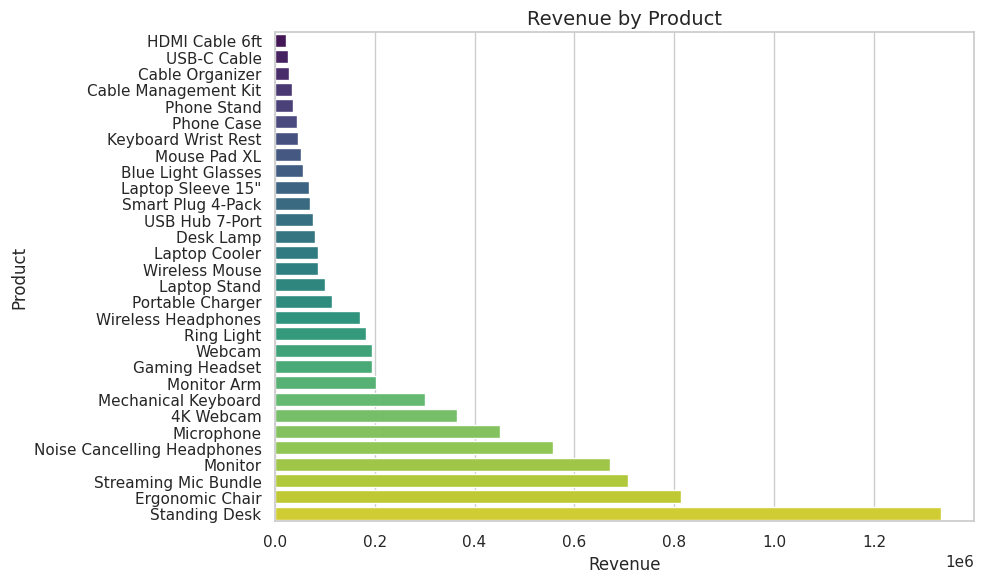

In [47]:
plt.figure(figsize=(10,6))

product_rev = df.groupby("product")["revenue"].sum().sort_values()

sns.barplot(
    x=product_rev.values,
    y=product_rev.index,
    palette="viridis"
)

plt.title("Revenue by Product", fontsize=14)
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

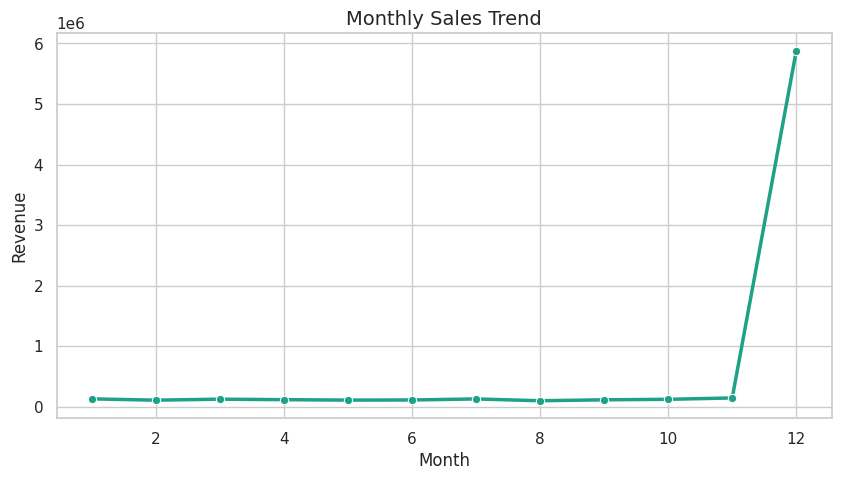

In [48]:
plt.figure(figsize=(10,5))

monthly_sales = df.groupby("month")["revenue"].sum()

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o",
    linewidth=2.5,
    color=palette[3]
)

plt.title("Monthly Sales Trend", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

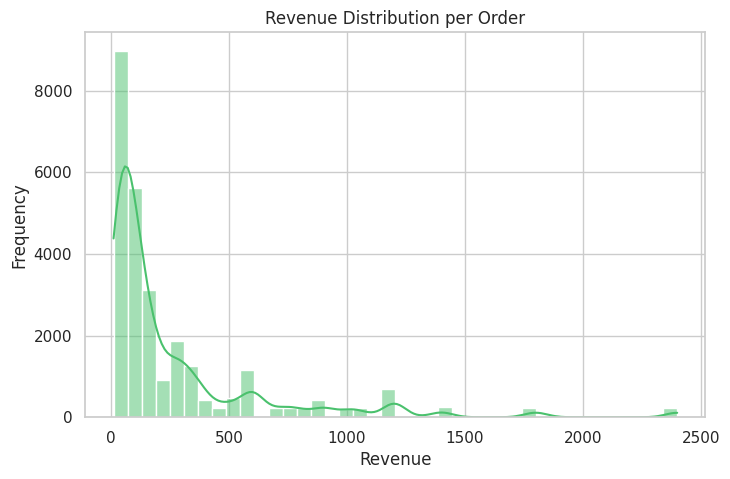

In [49]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["revenue"],
    bins=40,
    kde=True,
    color=palette[4]
)

plt.title("Revenue Distribution per Order")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()

/tmp/ipykernel_1740/1544596675.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


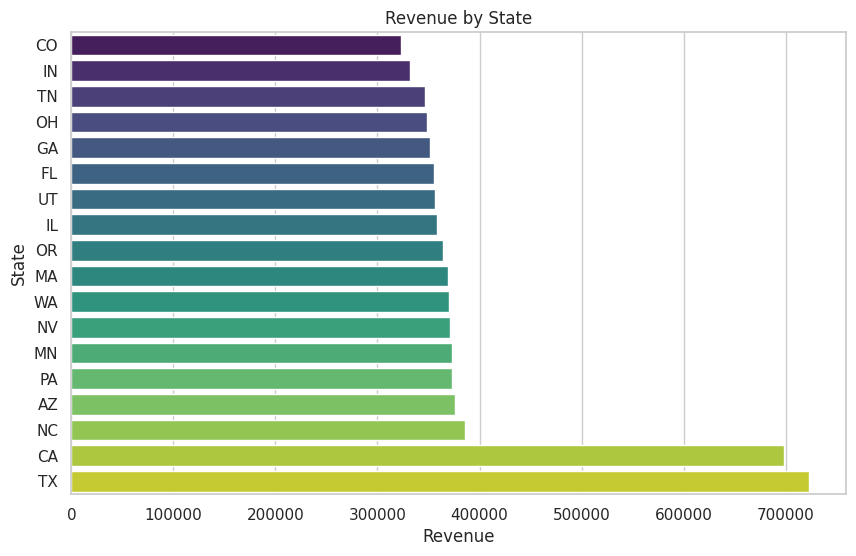

In [50]:
plt.figure(figsize=(10,6))

state_sales = df.groupby("state")["revenue"].sum().sort_values()

sns.barplot(
    x=state_sales.values,
    y=state_sales.index,
    palette="viridis"
)

plt.title("Revenue by State")
plt.xlabel("Revenue")
plt.ylabel("State")

plt.show()

/tmp/ipykernel_1740/3862611962.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


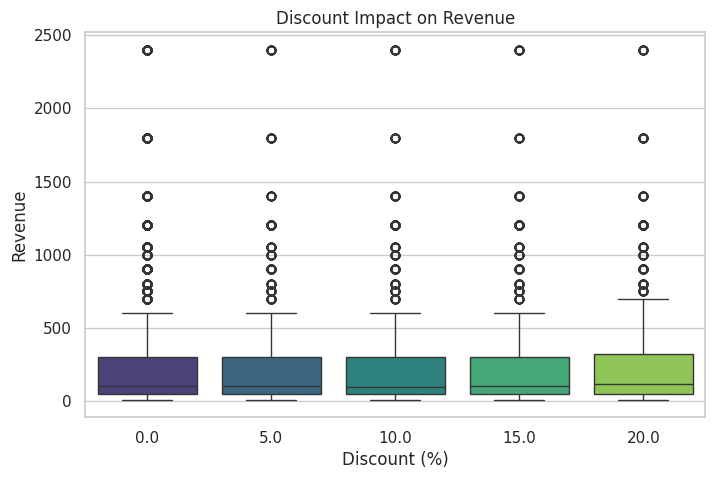

In [51]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="discount",
    y="revenue",
    data=df,
    palette="viridis"
)

plt.title("Discount Impact on Revenue")
plt.xlabel("Discount (%)")
plt.ylabel("Revenue")

plt.show()

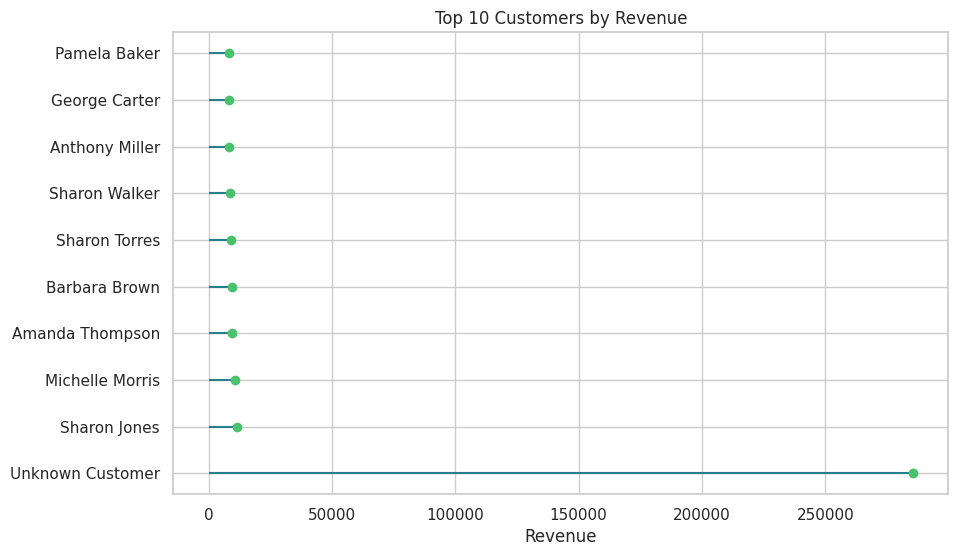

In [52]:
top_customers = df.groupby("customer_name")["revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

plt.hlines(y=top_customers.index, xmin=0, xmax=top_customers.values, color=palette[2])
plt.plot(top_customers.values, top_customers.index, "o", color=palette[4])

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")

plt.show()

/tmp/ipykernel_1740/865498024.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


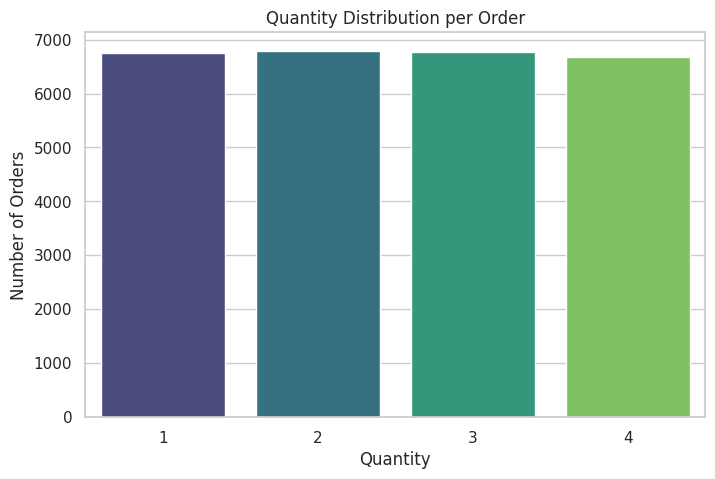

In [53]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="qty",
    data=df,
    palette="viridis"
)

plt.title("Quantity Distribution per Order")
plt.xlabel("Quantity")
plt.ylabel("Number of Orders")

plt.show()

##Business Insights

In [55]:
# *The top 3 products Standing Desk, Ergonomic Chair, and Streaming Mic
#   Bundle account for nearly 40% of total revenue, revealing a strong
#   concentration in high-ticket office furniture and equipment.
# *Revenue is geographically skewed, with TX and CA alone contributing over 20%
#   of total sales, while the remaining 18 states split the rest.
# *December accounts for a disproportionate share of annual revenue, dwarfing
#   every other month and suggesting a strong end of year purchasing spike driven
#   by holiday or budget flush buying.
# *Over half of all orders (57%) include a discount, indicating heavy reliance on
#   promotions to drive conversions across the customer base.
# *Repeat buyers represent just 55% of customers yet drive 77% of total revenue, making customer retention the single most important lever for sustaining sales performance.

In [54]:
df.to_csv("clean_sales_data.csv", index=False)